In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/00365.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/01574.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/00185.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/01048.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/01673.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/01598.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/00808.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/00573.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/01692.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/00679.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-folder/val/2_erythroblast/01317.png
/kaggle/input/datasets/cyizhuo/bloodmnist-2828-by-fold

In [2]:
!pip install shap -q


## CELL 2: Build CSVs (with clean label names)

import os, glob, re
import pandas as pd
from sklearn.model_selection import train_test_split

IMG_EXTS = ("jpg", "jpeg", "png", "bmp", "tif", "tiff")
SPLIT_ALIASES = {"train": "train", "training": "train",
                  "val": "val", "valid": "val", "validation": "val",
                  "test": "test", "testing": "test"}

all_imgs = []
for ext in IMG_EXTS:
    all_imgs.extend(glob.glob(f"/kaggle/input/**/*.{ext}", recursive=True))
    all_imgs.extend(glob.glob(f"/kaggle/input/**/*.{ext.upper()}", recursive=True))
all_imgs = sorted(set(all_imgs))
print("total images found:", len(all_imgs))

rows = []
for p in all_imgs:
    parts = p.split(os.sep)
    label = parts[-2]
    split_guess = parts[-3].lower() if len(parts) >= 3 else ""
    rows.append({"image_path": p, "label": label, "split": SPLIT_ALIASES.get(split_guess)})

df = pd.DataFrame(rows)
df["label"] = df["label"].apply(lambda l: re.sub(r'^\d+_', '', l))
print("labels:", sorted(df["label"].unique()))

df2 = df.dropna(subset=["split"])
train_df = df2[df2["split"] == "train"][["image_path", "label"]].reset_index(drop=True)
val_df   = df2[df2["split"] == "val"][["image_path", "label"]].reset_index(drop=True)
test_df  = df2[df2["split"] == "test"][["image_path", "label"]].reset_index(drop=True)

os.makedirs("/kaggle/working/shuffled_csvs", exist_ok=True)
train_df.to_csv("/kaggle/working/shuffled_csvs/train_shuffled.csv", index=False)
val_df.to_csv  ("/kaggle/working/shuffled_csvs/val_shuffled.csv",   index=False)
test_df.to_csv ("/kaggle/working/shuffled_csvs/test_shuffled.csv",  index=False)

print(f"train={len(train_df)} val={len(val_df)} test={len(test_df)}")
print(train_df["label"].value_counts())

total images found: 17092
labels: ['basophil', 'eosinophil', 'erythroblast', 'immature_granulocytes', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
train=11959 val=1712 test=3421
label
neutrophil               2330
eosinophil               2181
immature_granulocytes    2026
platelet                 1643
erythroblast             1085
monocyte                  993
basophil                  852
lymphocyte                849
Name: count, dtype: int64


In [4]:
## CELL 3: Imports, Config, Dataset, transforms
import os, random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              precision_recall_fscore_support, matthews_corrcoef,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class Config:
    IMG_SIZE = 224
    BATCH_SIZE = 64
    EPOCHS = 50
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    NUM_CLASSES = 8
    TOPK_MAX = 8
    GNN_HIDDEN = 256
    GNN_LAYERS = 3
    FEAT_DIM = 2048
    CKPT_DIR = "/kaggle/working/checkpoints"
    IMG_COL = "image_path"
    LABEL_COL = "label"

cfg = Config()
os.makedirs(cfg.CKPT_DIR, exist_ok=True)

class BloodCellDataset(Dataset):
    def __init__(self, df, label2idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.label2idx = label2idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row[cfg.IMG_COL], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = self.label2idx[row[cfg.LABEL_COL]]
        return img, label

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])


In [5]:
## CELL 4: Backbone + Adaptive Neighborhood MLP + Edge Weight Predictor + Graph construction + TAL-GRN layer/model

class Backbone(nn.Module):
    def __init__(self, freeze=True):
        super().__init__()
        net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(net.children())[:-1])
        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x):
        return self.features(x).flatten(1)

class AdaptiveNeighborhoodMLP(nn.Module):
    def __init__(self, in_dim, topk_max):
        super().__init__()
        self.topk_max = topk_max
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, feats):
        k_frac = self.net(feats).squeeze(-1)
        return 2 + k_frac * (self.topk_max - 2)

class EdgeWeightPredictor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim * 2 + 1, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, fi, fj, cos_sim):
        x = torch.cat([fi, fj, cos_sim.unsqueeze(-1)], dim=-1)
        return self.net(x).squeeze(-1)

def build_graph(feats, neighbor_mlp, edge_predictor, topk_max):
    B = feats.size(0)
    feats_n = F.normalize(feats, dim=-1)
    sim = feats_n @ feats_n.t()
    sim.fill_diagonal_(-1e4)

    k_pred = neighbor_mlp(feats)
    k_int = torch.clamp(k_pred.round().long(), 2, min(topk_max, B - 1))

    src, dst, ew = [], [], []
    for i in range(B):
        k_i = k_int[i].item()
        topk_val, topk_idx = torch.topk(sim[i], k_i)
        fi = feats[i].unsqueeze(0).expand(k_i, -1)
        fj = feats[topk_idx]
        w = edge_predictor(fi, fj, topk_val)
        src.extend([i] * k_i)
        dst.extend(topk_idx.tolist())
        ew.append(w)

    edge_index = torch.tensor([src, dst], dtype=torch.long, device=feats.device)
    edge_weight = torch.cat(ew, dim=0)
    return edge_index, edge_weight

class TALGRNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x, edge_index, edge_weight):
        src, dst = edge_index
        N = x.size(0)
        messages = x[src] * edge_weight.unsqueeze(-1)
        agg = torch.zeros(N, x.size(1), device=x.device, dtype=x.dtype)
        agg.index_add_(0, dst, messages)
        deg = torch.zeros(N, device=x.device, dtype=x.dtype).index_add_(0, dst, edge_weight) + 1e-6
        agg = agg / deg.unsqueeze(-1)
        out = self.lin_self(x) + self.lin_neigh(agg)
        return F.relu(self.norm(out))

class TALGRN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = Backbone(freeze=True)
        self.neighbor_mlp = AdaptiveNeighborhoodMLP(cfg.FEAT_DIM, cfg.TOPK_MAX)
        self.edge_predictor = EdgeWeightPredictor(cfg.FEAT_DIM)
        dims = [cfg.FEAT_DIM] + [cfg.GNN_HIDDEN] * cfg.GNN_LAYERS
        self.gnn_layers = nn.ModuleList([TALGRNLayer(dims[i], dims[i+1]) for i in range(cfg.GNN_LAYERS)])
        self.classifier = nn.Sequential(
            nn.Linear(cfg.GNN_HIDDEN, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, cfg.NUM_CLASSES)
        )
        self.topk_max = cfg.TOPK_MAX

    def forward(self, x):
        feats = self.backbone(x)
        edge_index, edge_weight = build_graph(feats, self.neighbor_mlp, self.edge_predictor, self.topk_max)
        h = feats
        for layer in self.gnn_layers:
            h = layer(h, edge_index, edge_weight)
        return self.classifier(h)

In [6]:
## CELL 5: Metrics + checkpoint utils

def compute_metrics(y_true, y_pred, y_prob, class_names):
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    return {"accuracy": acc, "balanced_accuracy": bacc,
            "precision_macro": prec_m, "recall_macro": rec_m, "f1_macro": f1_m,
            "precision_weighted": prec_w, "recall_weighted": rec_w, "f1_weighted": f1_w,
            "mcc": mcc, "report": report}

def pretty_print_metrics(m, split_name=""):
    print(f"\n── {split_name} metrics ──")
    print(f"Accuracy:            {m['accuracy']:.4f}")
    print(f"Balanced Accuracy:   {m['balanced_accuracy']:.4f}")
    print(f"F1 (macro):          {m['f1_macro']:.4f}")
    print(f"F1 (weighted):       {m['f1_weighted']:.4f}")
    print(f"MCC:                 {m['mcc']:.4f}")
    print(m["report"])

def save_checkpoint(model, optimizer, epoch, best_f1, path):
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "epoch": epoch, "best_f1": best_f1}, path)

def load_checkpoint(model, optimizer, path):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt["optimizer"])
    return ckpt["epoch"], ckpt["best_f1"]

In [7]:
## CELL 6: Train/eval loop + main training function

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_true, all_pred, all_prob = [], [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            probs = F.softmax(logits, dim=-1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(probs.argmax(-1).cpu().numpy())
            all_prob.extend(probs.detach().cpu().numpy())
    return total_loss / len(loader.dataset), np.array(all_true), np.array(all_pred), np.array(all_prob)

def train_talgrn(train_df, val_df, class_names):
    label2idx = {c: i for i, c in enumerate(class_names)}
    train_loader = DataLoader(BloodCellDataset(train_df, label2idx, train_tf), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(BloodCellDataset(val_df, label2idx, eval_tf), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = TALGRN(cfg).to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1 = -1.0
    best_path = os.path.join(cfg.CKPT_DIR, "talgrn_bloodmnist_best.pt")

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, _, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, y_true, y_pred, y_prob = run_epoch(model, val_loader, criterion, None)
        scheduler.step()
        m = compute_metrics(y_true, y_pred, y_prob, class_names)
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss); history["val_f1"].append(m["f1_macro"])
        print(f"Epoch {epoch:02d}/{cfg.EPOCHS} | train_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
              f"val_f1_macro={m['f1_macro']:.4f} val_bacc={m['balanced_accuracy']:.4f}")
        if m["f1_macro"] > best_f1:
            best_f1 = m["f1_macro"]
            save_checkpoint(model, optimizer, epoch, best_f1, best_path)
            print(f"   ↳ new best (f1_macro={best_f1:.4f}) saved")

    return model, optimizer, history, best_path

In [8]:
##  CELL 7: Plotting + final test + Grad-CAM

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="train"); axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["val_f1"], color="green"); axes[1].set_title("Validation F1 (macro)")
    plt.tight_layout(); plt.show()

def plot_confusion(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
    plt.tight_layout(); plt.show()

def final_test(model, test_df, class_names, ckpt_path):
    label2idx = {c: i for i, c in enumerate(class_names)}
    test_loader = DataLoader(BloodCellDataset(test_df, label2idx, eval_tf), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
    load_checkpoint(model, None, ckpt_path)
    _, y_true, y_pred, y_prob = run_epoch(model, test_loader, nn.CrossEntropyLoss(), None)
    m = compute_metrics(y_true, y_pred, y_prob, class_names)
    pretty_print_metrics(m, "TEST")
    plot_confusion(y_true, y_pred, class_names)
    return m, y_true, y_pred, y_prob

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer = model.backbone.features[-3]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
        logits = self.model(img_tensor)
        if class_idx is None:
            class_idx = logits.argmax(-1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=(cfg.IMG_SIZE, cfg.IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

def show_gradcam(model, df, class_names, n=4):
    gc = GradCAM(model)
    label2idx = {c: i for i, c in enumerate(class_names)}
    ds = BloodCellDataset(df.sample(n, random_state=SEED), label2idx, eval_tf)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for i in range(n):
        img_t, label = ds[i]
        cam, pred_idx = gc.generate(img_t, None)
        raw = (img_t.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET) / 255.0
        overlay = 0.55 * raw + 0.45 * heat[..., ::-1]
        axes[0, i].imshow(raw); axes[0, i].set_title(f"true={class_names[label]}"); axes[0, i].axis("off")
        axes[1, i].imshow(overlay); axes[1, i].set_title(f"pred={class_names[pred_idx]}"); axes[1, i].axis("off")
    plt.tight_layout(); plt.show()


classes: ['basophil', 'eosinophil', 'erythroblast', 'immature_granulocytes', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Epoch 01/50 | train_loss=1.5389 val_loss=1.0237 val_f1_macro=0.4937 val_bacc=0.5373
   ↳ new best (f1_macro=0.4937) saved
Epoch 02/50 | train_loss=0.9221 val_loss=0.8148 val_f1_macro=0.6133 val_bacc=0.6328
   ↳ new best (f1_macro=0.6133) saved
Epoch 03/50 | train_loss=0.7673 val_loss=0.7335 val_f1_macro=0.6482 val_bacc=0.6693
   ↳ new best (f1_macro=0.6482) saved
Epoch 04/50 | train_loss=0.7003 val_loss=0.6919 val_f1_macro=0.7127 val_bacc=0.7174
   ↳ new best (f1_macro=0.7127) saved
Epoch 05/50 | train_loss=0.6460 val_loss=0.6896 val_f1_macro=0.7204 val_bacc=0.7357
   ↳ new best (f1_macro=0.7204) saved
Epoch 06/50 | train_loss=0.5955 val_loss=0.6827 val_f1_macro=0.7178 val_bacc=0.7244
Epoch 07/50 | train_loss=0.5896 val_loss=0.7244 val_f1_macro=0.6976 val_bacc=0.7278
Epoch 08/50 | train_loss=0.5474 val_loss=0.6376 val_f1_macro=0.7246 val_bacc=0.7303
   ↳ new best (f1_macro=0.7246) saved
Epoch 09/50 | train_loss=0.5518 val_loss=0.6603 val_f1_macro=0.7205 val_bacc=0.7363
Epoch 10/50 | tr

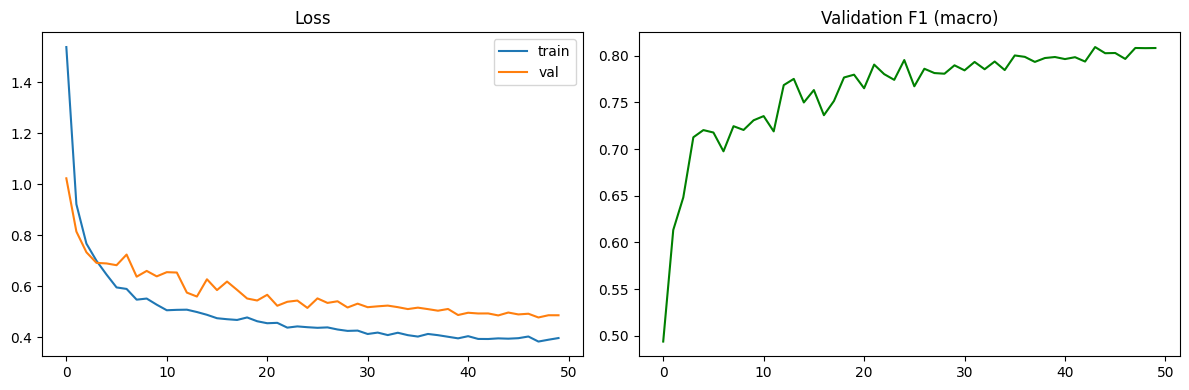


── TEST metrics ──
Accuracy:            0.8062
Balanced Accuracy:   0.7790
F1 (macro):          0.7774
F1 (weighted):       0.8056
MCC:                 0.7741
                       precision    recall  f1-score   support

             basophil       0.61      0.66      0.63       244
           eosinophil       0.95      0.92      0.94       624
         erythroblast       0.71      0.86      0.77       311
immature_granulocytes       0.67      0.68      0.67       579
           lymphocyte       0.79      0.82      0.80       243
             monocyte       0.69      0.51      0.59       284
           neutrophil       0.85      0.91      0.88       666
             platelet       0.99      0.88      0.93       470

             accuracy                           0.81      3421
            macro avg       0.78      0.78      0.78      3421
         weighted avg       0.81      0.81      0.81      3421



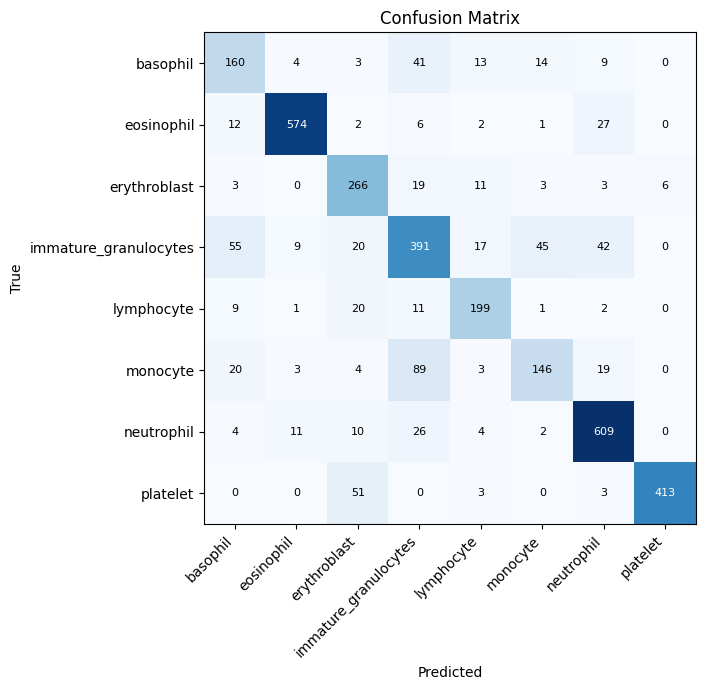

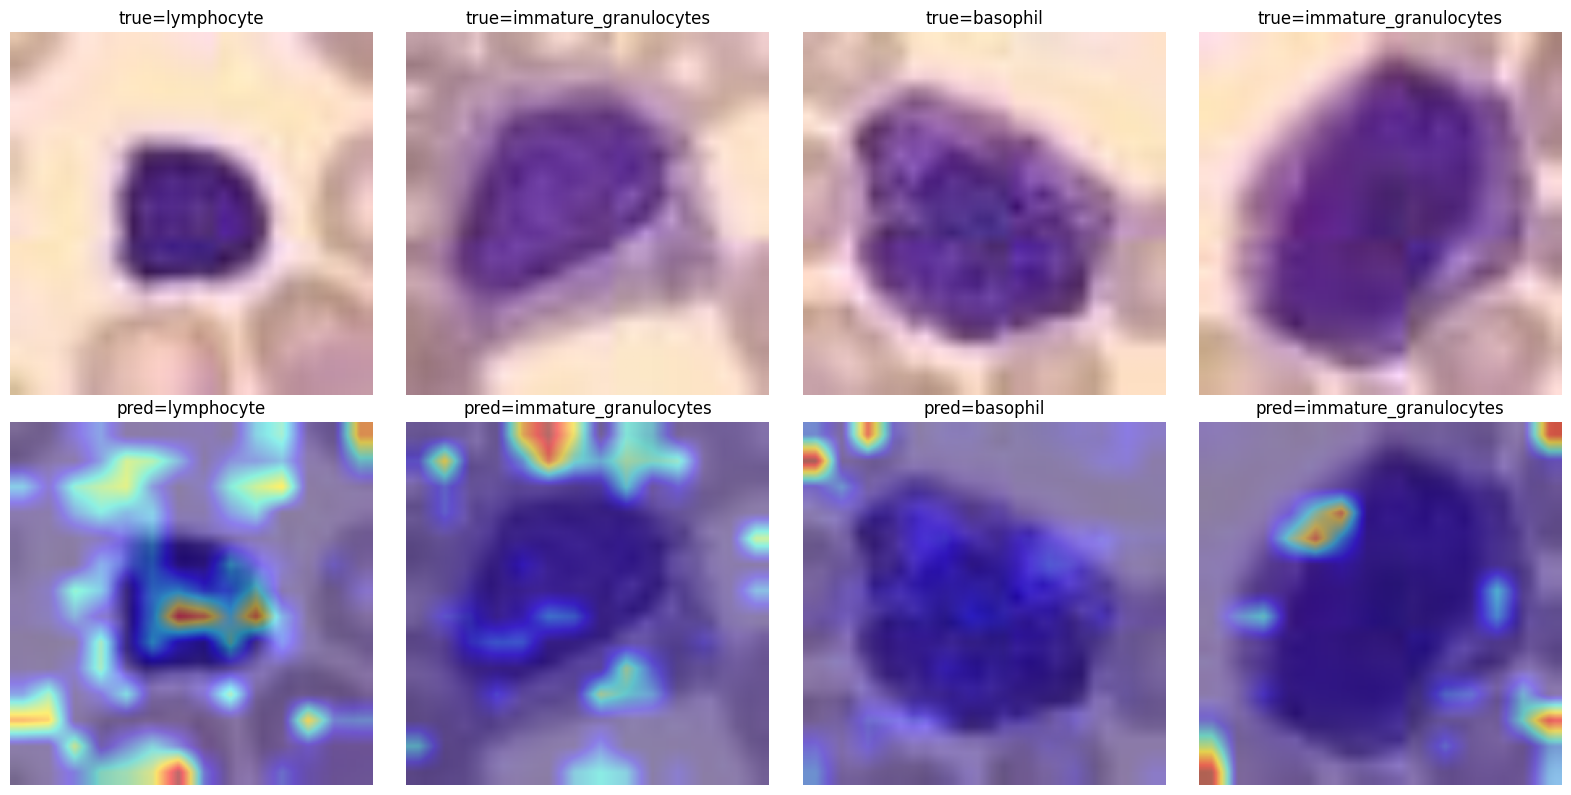

In [9]:
## CELL 8: Run everything

train_df = pd.read_csv("/kaggle/working/shuffled_csvs/train_shuffled.csv")
val_df   = pd.read_csv("/kaggle/working/shuffled_csvs/val_shuffled.csv")
test_df  = pd.read_csv("/kaggle/working/shuffled_csvs/test_shuffled.csv")

class_names = sorted(train_df["label"].unique())
cfg.NUM_CLASSES = len(class_names)
print("classes:", class_names)

model, optimizer, history, best_path = train_talgrn(train_df, val_df, class_names)
plot_history(history)
metrics, y_true, y_pred, y_prob = final_test(model, test_df, class_names, best_path)
show_gradcam(model, test_df, class_names, n=4)

In [10]:
## CELL 9: Vanilla ResNet50 model

class VanillaResNet50(nn.Module):
    def __init__(self, num_classes, freeze=False):
        super().__init__()
        net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if freeze:
            for p in net.parameters():
                p.requires_grad = False
        in_feats = net.fc.in_features
        net.fc = nn.Linear(in_feats, num_classes)
        self.net = net

    def forward(self, x):
        return self.net(x)

In [11]:
## train vanilla ResNet50
def train_vanilla_resnet(train_df, val_df, class_names, freeze=False):
    label2idx = {c: i for i, c in enumerate(class_names)}
    train_loader = DataLoader(BloodCellDataset(train_df, label2idx, train_tf), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(BloodCellDataset(val_df, label2idx, eval_tf), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = VanillaResNet50(cfg.NUM_CLASSES, freeze=freeze).to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1 = -1.0
    tag = "frozen" if freeze else "unfrozen"
    best_path = os.path.join(cfg.CKPT_DIR, f"vanilla_resnet50_{tag}_bloodmnist_best.pt")

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, _, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, y_true, y_pred, y_prob = run_epoch(model, val_loader, criterion, None)
        scheduler.step()
        m = compute_metrics(y_true, y_pred, y_prob, class_names)
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss); history["val_f1"].append(m["f1_macro"])
        print(f"[vanilla-{tag}] Epoch {epoch:02d}/{cfg.EPOCHS} | train_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
              f"val_f1_macro={m['f1_macro']:.4f} val_bacc={m['balanced_accuracy']:.4f}")
        if m["f1_macro"] > best_f1:
            best_f1 = m["f1_macro"]
            save_checkpoint(model, optimizer, epoch, best_f1, best_path)
            print(f"   ↳ new best (f1_macro={best_f1:.4f}) saved")

    return model, optimizer, history, best_path

def final_test_vanilla(model, test_df, class_names, ckpt_path):
    label2idx = {c: i for i, c in enumerate(class_names)}
    test_loader = DataLoader(BloodCellDataset(test_df, label2idx, eval_tf), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
    load_checkpoint(model, None, ckpt_path)
    _, y_true, y_pred, y_prob = run_epoch(model, test_loader, nn.CrossEntropyLoss(), None)
    m = compute_metrics(y_true, y_pred, y_prob, class_names)
    pretty_print_metrics(m, "VANILLA RESNET50 — TEST")
    plot_confusion(y_true, y_pred, class_names)
    return m, y_true, y_pred, y_prob


[vanilla-frozen] Epoch 01/50 | train_loss=1.8953 val_loss=1.8150 val_f1_macro=0.3098 val_bacc=0.3758
   ↳ new best (f1_macro=0.3098) saved
[vanilla-frozen] Epoch 02/50 | train_loss=1.6597 val_loss=1.6703 val_f1_macro=0.3872 val_bacc=0.4411
   ↳ new best (f1_macro=0.3872) saved
[vanilla-frozen] Epoch 03/50 | train_loss=1.4948 val_loss=1.5536 val_f1_macro=0.4281 val_bacc=0.4761
   ↳ new best (f1_macro=0.4281) saved
[vanilla-frozen] Epoch 04/50 | train_loss=1.3811 val_loss=1.4544 val_f1_macro=0.4735 val_bacc=0.5045
   ↳ new best (f1_macro=0.4735) saved
[vanilla-frozen] Epoch 05/50 | train_loss=1.2784 val_loss=1.3754 val_f1_macro=0.5215 val_bacc=0.5414
   ↳ new best (f1_macro=0.5215) saved
[vanilla-frozen] Epoch 06/50 | train_loss=1.2038 val_loss=1.3132 val_f1_macro=0.5220 val_bacc=0.5387
   ↳ new best (f1_macro=0.5220) saved
[vanilla-frozen] Epoch 07/50 | train_loss=1.1413 val_loss=1.2720 val_f1_macro=0.5429 val_bacc=0.5590
   ↳ new best (f1_macro=0.5429) saved
[vanilla-frozen] Epoch 08/5

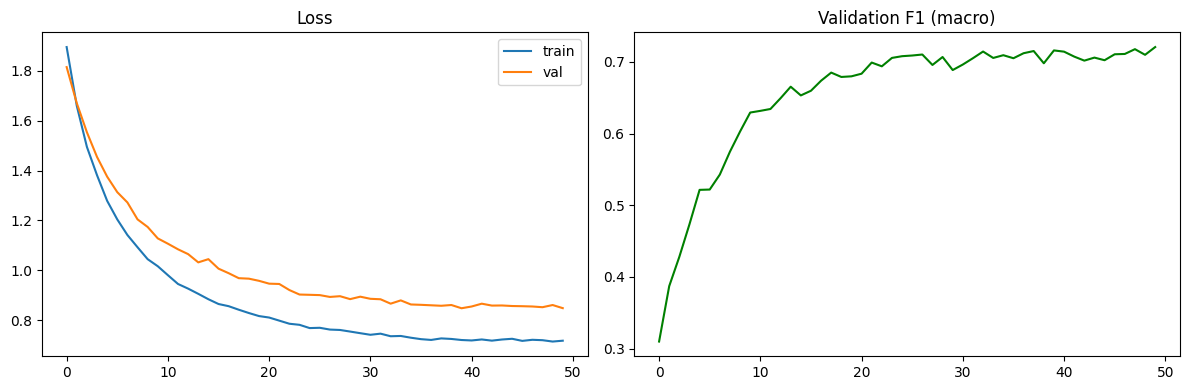


── VANILLA RESNET50 — TEST metrics ──
Accuracy:            0.7553
Balanced Accuracy:   0.7068
F1 (macro):          0.7039
F1 (weighted):       0.7430
MCC:                 0.7151
                       precision    recall  f1-score   support

             basophil       0.57      0.51      0.54       244
           eosinophil       0.88      0.90      0.89       624
         erythroblast       0.73      0.72      0.73       311
immature_granulocytes       0.65      0.65      0.65       579
           lymphocyte       0.65      0.83      0.73       243
             monocyte       0.76      0.25      0.38       284
           neutrophil       0.73      0.93      0.82       666
             platelet       0.95      0.87      0.91       470

             accuracy                           0.76      3421
            macro avg       0.74      0.71      0.70      3421
         weighted avg       0.76      0.76      0.74      3421



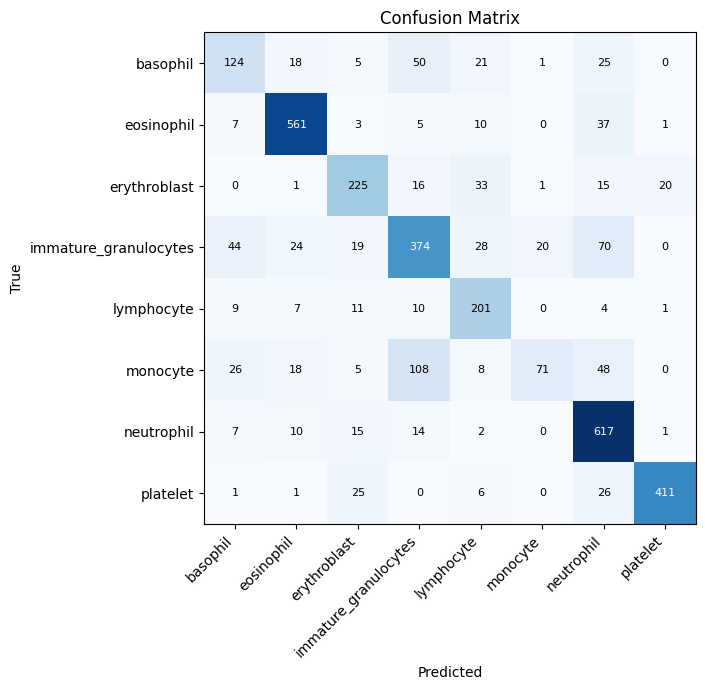


═══ Frozen Vanilla vs Unfrozen Vanilla vs TAL-GRN ═══
Metric                  Frozen Vanilla  Unfrozen Vanilla     TAL-GRN


NameError: name 'vanilla_metrics' is not defined

In [12]:
frozen_model, frozen_opt, frozen_history, frozen_best_path = train_vanilla_resnet(
    train_df, val_df, class_names, freeze=True
)
plot_history(frozen_history)
frozen_metrics, f_y_true, f_y_pred, f_y_prob = final_test_vanilla(
    frozen_model, test_df, class_names, frozen_best_path
)

print("\n═══ Frozen Vanilla vs Unfrozen Vanilla vs TAL-GRN ═══")
print(f"{'Metric':<22}{'Frozen Vanilla':>16}{'Unfrozen Vanilla':>18}{'TAL-GRN':>12}")
for k in ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted", "mcc"]:
    print(f"{k:<22}{frozen_metrics[k]:>16.4f}{vanilla_metrics[k]:>18.4f}{metrics[k]:>12.4f}")